First, we'll load the dataset and display the first few rows, along with the dimensions of the data to get an overview.

In [31]:
import pandas as pd

# Cargar el conjunto de datos
file_path = "challenge - dataset.csv"
df = pd.read_csv(file_path)

# Mostrar las primeras filas del conjunto de datos
print("Primeras filas del conjunto de datos:")
print(df.head())
# Dimensiones de mis datos
print("Dimensiones del conjunto de datos:")
print(df.shape)

Primeras filas del conjunto de datos:
                         id   nif_code              web_site  \
0  5b133284a6da98dccdde5f03  B53876694     palomabarcelo.com   
1  556d34fd7369641226dab000  B37020187             beher.com   
2  5e57ea61d5bd4a000176bd7c  B93643716  aguacateradelsur.com   
3  5e581dba9064ba0001ceb925  A48980122           altegui.com   
4  5e55a840831f070001de01d2  B74215559        siliciumg5.com   

                                        linkedin_url  \
0      http://www.linkedin.com/company/palomabarcelo   
1  http://www.linkedin.com/company/beher-switzerland   
2         http://www.linkedin.com/company/aguacatera   
3     http://www.linkedin.com/company/dux-inversores   
4        http://www.linkedin.com/company/siliciumlab   

                                               about  Label  \
0  " High quality and perfection are the result o...      0   
1  "BEST HAM IN THE WORLD"​- IFFA International F...      0   
2  "El mundo necesita gente como La Aguacatera, q..

Knowing the nature of the data, we can remove some columns that we know will not be needed for our task.

In [32]:
# Lista de columnas a eliminar
columns_to_drop = [
    "id", "nif_code", "web_site", "linkedin_url", "website_url",
    "blog_url", "angellist_url", "facebook_url", "primary_phone",
    "alexa_ranking", "phone", "linkedin_uid", "primary_domain",
    "persona_counts", "num_suborganizations", "name", "location",
    "location_x", "location_y"
]

# Eliminar las columnas del DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

After removing the columns, let's visualize the first few rows again.

In [33]:
# Mostrar las primeras filas del DataFrame limpio
print("Primeras filas del DataFrame limpio:")
print(df_cleaned.head())

Primeras filas del DataFrame limpio:
                                               about  Label  \
0  " High quality and perfection are the result o...      0   
1  "BEST HAM IN THE WORLD"​- IFFA International F...      0   
2  "El mundo necesita gente como La Aguacatera, q...      0   
3  "El valor del trabajo bien hecho"​\n\nSomos un...      0   
4  "Fabricación y distribución de complementos al...      1   

                           twitter_url    languages  \
0                                  NaN           []   
1                                  NaN  ['English']   
2                                  NaN           []   
3                                  NaN           []   
4  https://twitter.com/SiliciumEspagne           []   

                                            keywords  \
0              ['diseno', 'calzado', 'moda', 'lujo']   
1  ['acornfed ham', 'jamon iberico de bellota', '...   
2                                       ['avocados']   
3  ['asset management', 'cicl

It is observed that some values are null, and upon further observation, some columns with numerous null values can also be removed.

In [34]:
# Contar valores NaN o null en cada columna
null_counts = df_cleaned.isnull().sum()

# Mostrar el número de valores NaN o null en cada columna
print("Número de valores NaN o null en cada columna:")
print(null_counts)

# Eliminar las columnas especificadas con numerosos null
columns_to_drop = ["twitter_url", "specialities_x", "specialities_y", "specialities"]
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

Número de valores NaN o null en cada columna:
about                   0
Label                   0
twitter_url          1906
languages               0
keywords                0
short_description      29
specialities_x       1070
specialities_y       2832
specialities         2747
dtype: int64


For other fields that were in the same situation, we decided not to delete them because they may be useful. For these fields, we filled empty values with an empty string. Let's visualize the DataFrame again after cleaning it.

In [35]:
# Rellenar el campo "short_description" con un valor de cadena vacía si es null/nan
df_cleaned["short_description"].fillna("", inplace=True)

# Mostrar las primeras filas del DataFrame después de la limpieza
print("Primeras filas del DataFrame después de la limpieza:")
print(df_cleaned.head())

Primeras filas del DataFrame después de la limpieza:
                                               about  Label    languages  \
0  " High quality and perfection are the result o...      0           []   
1  "BEST HAM IN THE WORLD"​- IFFA International F...      0  ['English']   
2  "El mundo necesita gente como La Aguacatera, q...      0           []   
3  "El valor del trabajo bien hecho"​\n\nSomos un...      0           []   
4  "Fabricación y distribución de complementos al...      1           []   

                                            keywords  \
0              ['diseno', 'calzado', 'moda', 'lujo']   
1  ['acornfed ham', 'jamon iberico de bellota', '...   
2                                       ['avocados']   
3  ['asset management', 'ciclo economico y sector...   
4  ['rosa mosqueta', 'g7 defender', 'silicium g5'...   

                                   short_description  
0  " High quality and perfection are the result o...  
1  "BEST HAM IN THE WORLD"- IFFA Internatio

To ensure the removal of possible fields with null values and verify if the cleaning has been done correctly, let's check the number of nulls again.


In [36]:
# Contar valores NaN o null en cada columna tras limpieza
null_counts = df_cleaned.isnull().sum()
# Mostrar el número de valores NaN o null en cada columna tras limpieza
print("Número de valores NaN o null en cada columna:")
print(null_counts)

Número de valores NaN o null en cada columna:
about                0
Label                0
languages            0
keywords             0
short_description    0
dtype: int64


Next, we can remove the stopwords. In this case, the languages ​​are Spanish and English. After this, we can also remove the 'languages' column as it does not provide much information.

In [37]:
# Eliminamos la columna language
df_cleaned = df_cleaned.drop(columns='languages')
# Descargar recursos de NLTK (stopwords en inglés y español)

# Librerias necesarias para esta tarea
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

# Obtener stopwords en inglés y español
stop_words_english = set(stopwords.words('english'))
stop_words_spanish = set(stopwords.words('spanish'))

# Combinar stopwords en inglés y español
stop_words_combined = stop_words_english.union(stop_words_spanish)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tutancamon\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tutancamon\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


After cleaning, we will start extracting information from our data. Sometimes it is possible to achieve good results without the need for complex algorithms. It may be that the mean, median, or another simpler statistical measure yields good results or provides valuable information for choosing the algorithm.

Next, we visualize the top 20 most frequent words. During the cleaning process, I noticed that the word "cada" had not been removed, but it was not useful for this task, so I added it as an extra stopword.

In [39]:
# Definir lista de palabras adicionales para eliminar
custom_stopwords = ["cada"]
# Definir función para tokenización y eliminación de stopwords
def preprocess_text(text):
    # Tokenización
    tokens = nltk.word_tokenize(text.lower())
    # Eliminación de stopwords
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words_combined and word not in custom_stopwords]
    return tokens

# Concatenar todos los perfiles de LinkedIn en un solo texto
all_text = ' '.join(df_cleaned['about'])

# Tokenización y eliminación de stopwords
tokens = preprocess_text(all_text)

# Conteo de frecuencia de palabras
word_freq = Counter(tokens)

# Visualización de las palabras más frecuentes
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

Let's visualize this data. In this case, I've chosen a histogram of the top 20 most common words (this is where I realized that the word "cada" should be added as an extra stopword) and a word cloud.

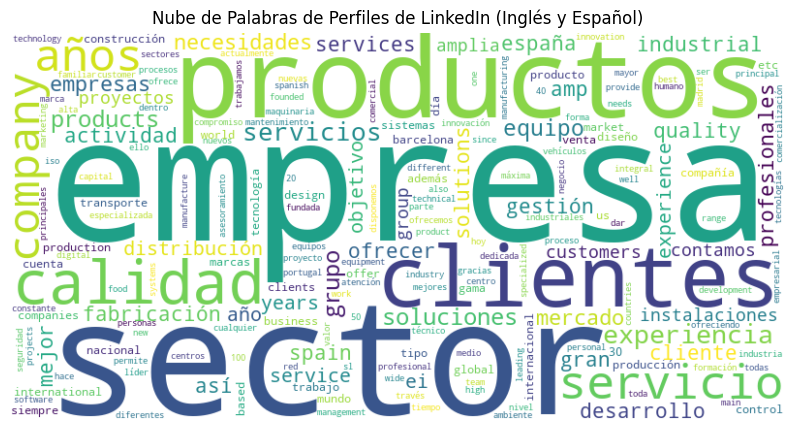

In [40]:
# Mostrar la nube de palabras
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Perfiles de LinkedIn (Inglés y Español)')
plt.show()

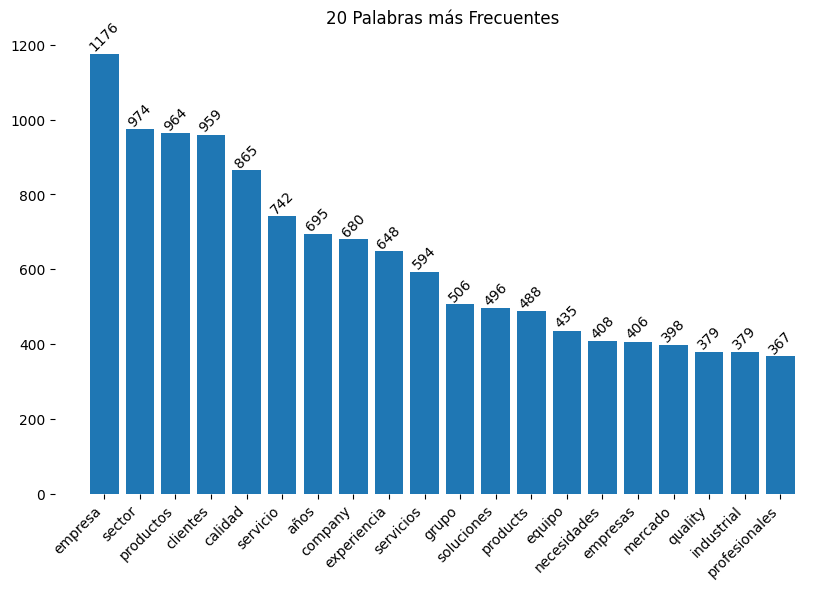

In [41]:
# Histograma de las 20 palabras más frecuentes
common_words = word_freq.most_common(20)
words, frequencies = zip(*common_words)

plt.figure(figsize=(10, 6))
bars = plt.bar(words, frequencies)
plt.title('20 Palabras más Frecuentes')
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, '%d' % int(height), ha='center', va='bottom', rotation=45)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['top'].set_visible(False) 
plt.gca().spines['right'].set_visible(False) 
plt.show()





Another good measure to study is which words are more frequently associated with the label 1.

In [42]:
from collections import defaultdict

# Crear un diccionario para almacenar el contador de cada palabra
word_counter = defaultdict(int)

# Iterar sobre cada registro en el DataFrame
for index, row in df_cleaned.iterrows():
    # Eliminar stopwords de la columna 'about' en este registro y mantener el orden
    about_words = [word for word in row['about'].split() if word not in stop_words_combined]
    
    # Iterar sobre cada palabra en 'about'
    for word in about_words:
        # Verificar el valor en la columna 'label' para este registro
        if row['Label'] == 1:
            word_counter[word] += 1  # Si label es 1, incrementar el contador para esta palabra
        else:
            word_counter[word] -= 1  # Si label es 0, decrementar el contador para esta palabra

# Ordenar las palabras según el contador en orden descendente
sorted_words = sorted(word_counter, key=word_counter.get, reverse=True)




We take advantage of this count to determine the number of different words, which will be useful for the future choice of algorithm.

In [43]:
print(len(sorted_words))

47693


We select the top 20 words. It's an arbitrary number. We will study the correlation of these words with the label.

In [44]:
# Seleccionar las palabras más relevantes basadas en el contador
top_words = sorted_words[:20]
df_cleaned_correlation = df_cleaned.copy()
# Crear columnas para cada palabra seleccionada
for word in top_words:
    df_cleaned_correlation[word] = df_cleaned['about'].apply(lambda x: 1 if word in x else 0)

# Calcular la correlación entre cada palabra seleccionada y la columna 'label'

correlation_results = {}
for word in top_words:
    correlation = df_cleaned['Label'].corr(df_cleaned_correlation[word])
    correlation_results[word] = correlation

We can visualize the words with their correlation and sort them for subsequent representation.

In [45]:
# Visualizar las correlaciones
print("Correlación entre las palabras más relevantes y la etiqueta 'label':")
for word, correlation in correlation_results.items():
    print(word, ":", correlation)

# Extraer las palabras y las correlaciones
words = list(correlation_results.keys())
correlations = list(correlation_results.values())

# Ordenar las palabras y correlaciones en función de la correlación de mayor a menor
sorted_words_correlations = sorted(zip(words, correlations), key=lambda x: x[1])

# Extraer las palabras y las correlaciones ordenadas
sorted_words = [pair[0] for pair in sorted_words_correlations]
sorted_correlations = [pair[1] for pair in sorted_words_correlations]

Correlación entre las palabras más relevantes y la etiqueta 'label':
residuos : 0.20091612602244935
sustainable : 0.17598113405075871
environmental : 0.20127372180942213
water : 0.1317912562732765
waste : 0.13549630403638108
wind : 0.0888295803267591
ambiente, : 0.1723089121044743
ambiental : 0.24113761381262422
energía : 0.15434505376105348
recycling : 0.10497656341464827
CO2 : 0.11321956653770711
energéticas : 0.05121469978180831
renewable : 0.12154614246049569
agua : 0.12441412970323934
Medio : 0.13461001627322883
maciza : 0.061401296119504456
sustainability : 0.13218561201705398
natural : 0.14798983110330938
treatment : 0.07507587609148837
language : 0.02370150421453773


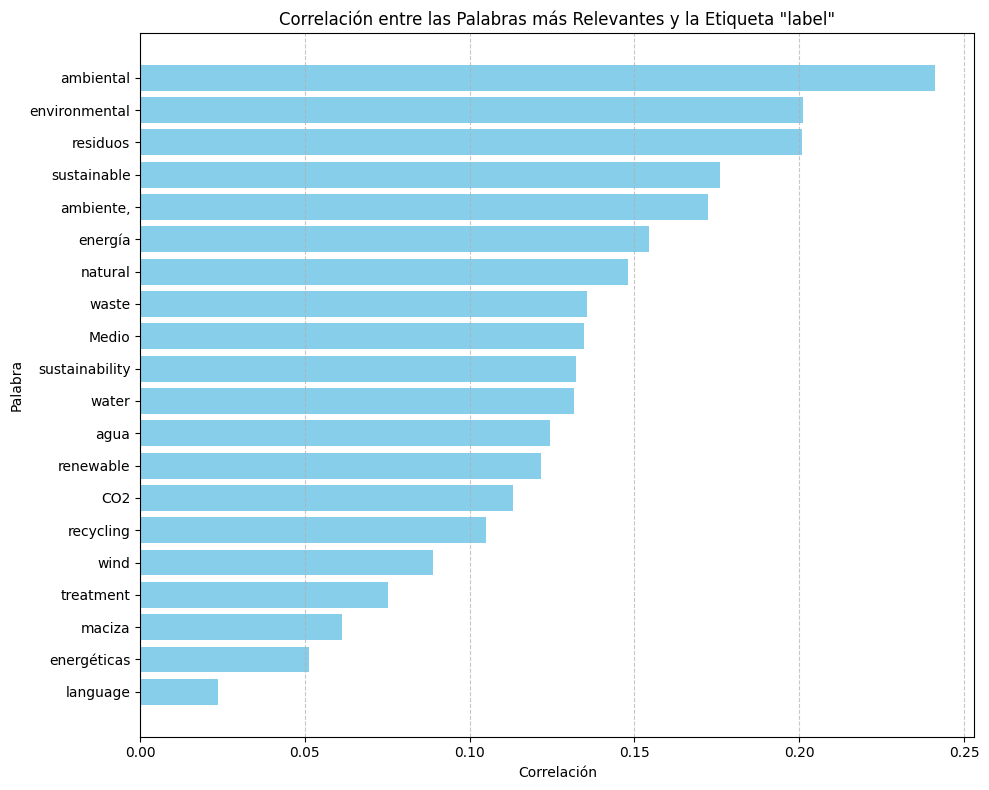

In [46]:
# Crear el gráfico de barras horizontales de las correlaciones
plt.figure(figsize=(10, 8))
plt.barh(sorted_words, sorted_correlations, color='skyblue')
plt.xlabel('Correlación')
plt.ylabel('Palabra')
plt.title('Correlación entre las Palabras más Relevantes y la Etiqueta "label"')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Another possible piece of information that can be obtained is whether there is any relationship between the words that appear most frequently and those that have the highest correlation with the label. It may happen that the repeated use of a word with high correlation causes false positives.

In [47]:
import numpy as np

# Obtener solo las palabras individuales de common_words
common_words = [word[0] for word in common_words]

# Crear un conjunto de palabras comunes
common_set = set(common_words)
sorted_set = set(top_words)

# Obtener las palabras comunes y no comunes
common_in_sorted = common_set.intersection(sorted_set)
print(common_in_sorted)




set()


As you can see, there are no results in the intersection, meaning that the most frequently appearing words are not necessarily those that are most strongly associated with the label value 1 (sustainable).

Another possible source of information is n-grams. We can study not only individual words but also groups of 2, 3, 4, n words and their relationship with the classification of sustainable or not sustainable.

First, let's perform the same stopwords removal, but this time we'll create a new field to store them at the level of each record. It's somewhat similar to keywords but done by me.

In [48]:
# Crear una copia del DataFrame original
df_cleaned_copy = df_cleaned.copy()

# Aplicar tokenización y eliminación de stopwords a cada registro en la columna 'about'
df_cleaned_copy['clean_about'] = df_cleaned_copy['about'].apply(preprocess_text)

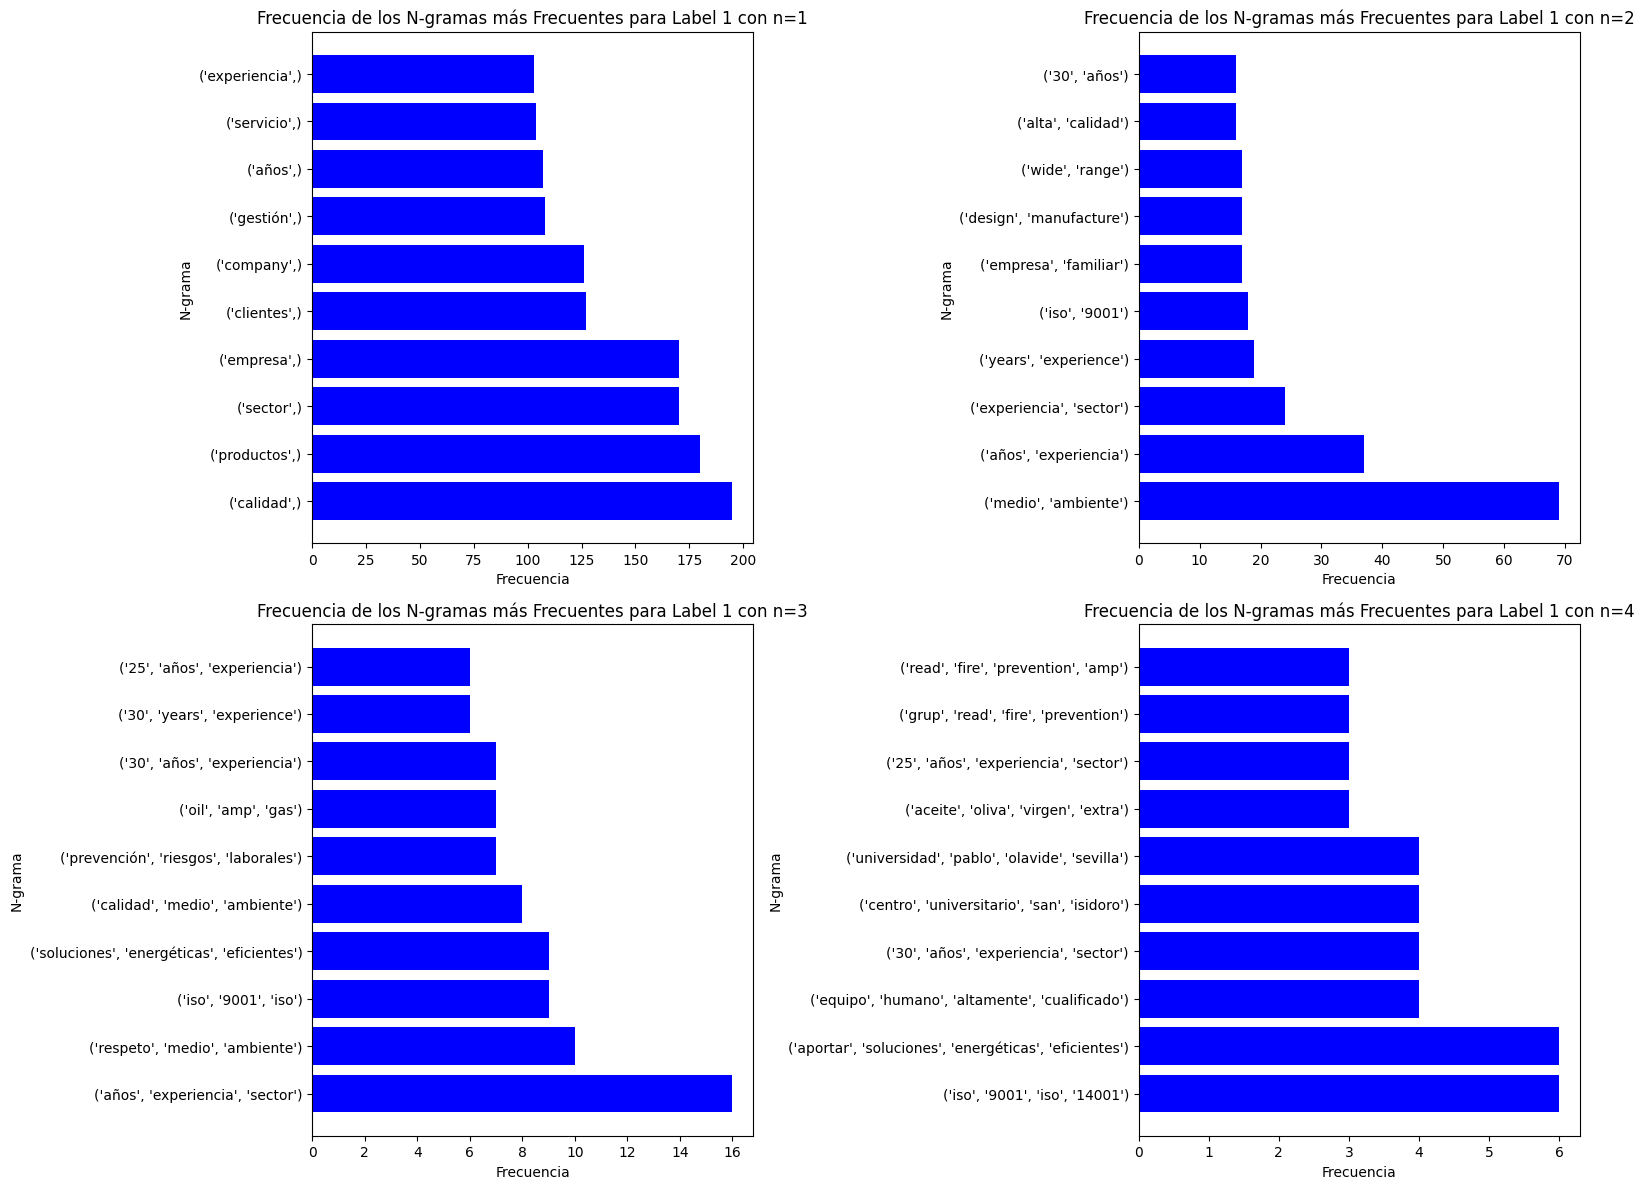

In [49]:
from nltk import ngrams
from collections import Counter

# Generación de n-gramas
def generate_ngrams(tokens, n):
    return list(ngrams(tokens, n))

# Definir los valores de n para los que quieres generar n-gramas
n_values = [1, 2, 3, 4]

# Aplicar la generación de n-gramas a la columna 'clean_about' para cada n
for n in n_values:
    df_cleaned_copy[f'ngrams_{n}'] = df_cleaned_copy['clean_about'].apply(lambda x: generate_ngrams(x, n))

# Análisis de frecuencia para cada n
ngram_freq = {n: {} for n in n_values}
for n in n_values:
    for label in df_cleaned_copy['Label'].unique():
        label_data = df_cleaned_copy[df_cleaned_copy['Label'] == label]
        ngram_freq[n][label] = Counter([gram for sublist in label_data[f'ngrams_{n}'] for gram in sublist])

# Configuración del gráfico
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # 2x2 grid para n=2,3,4,5
axes = axes.flatten()  # Convertir la matriz de ejes en un array plano

# Visualización de los n-gramas más frecuentes para cada n
for i, n in enumerate(n_values):
    # Obtener las frecuencias de n-gramas para la categoría con label 1
    label_1_freq = ngram_freq[n][1]
    
    # Obtener los n-gramas más frecuentes y sus frecuencias
    top_ngrams = label_1_freq.most_common(10)
    ngrams, frequencies = zip(*top_ngrams)
    
    # Crear un gráfico de barras horizontal en el subplot correspondiente
    axes[i].barh(np.arange(len(ngrams)), frequencies, color='blue')
    
    # Configuraciones del gráfico
    axes[i].set_yticks(np.arange(len(ngrams)))
    axes[i].set_yticklabels(ngrams)
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('N-grama')
    axes[i].set_title(f'Frecuencia de los N-gramas más Frecuentes para Label 1 con n={n}')

plt.tight_layout()
plt.show()

The issue with this analysis is that n-grams with high occurrence in records with the sustainable label may also appear in records with the non-sustainable label. That is, it doesn't penalize the appearance of these in labels with a value of 0.

This means that n-grams that are frequent in records with the label value 1 (sustainable) but also frequently appear in records with the label value 0 are not clearly distinguished as distinctive characteristics of the sustainable class.

To address this problem, you could consider applying association analysis techniques or feature selection methods that take into account the relative frequency of n-grams in each class. This could be a consideration for future development lines.

We're going to start by studying some characteristics of our data that are important for choosing the algorithm. Some of these characteristics have already been studied, such as the volume of data, and another one we need to look at is the balance. That is, how many records have the sustainability label as 0 or 1 out of the total.
More details about the characteristics of my data for algorithm selection are attached in the PDF document.

In [50]:
count_label = df_cleaned['Label'].value_counts()

# # Imprimir el resultado
print("Cantidad de veces que aparece el valor 0:", count_label[0])
print("Cantidad de veces que aparece el valor 1:", count_label[1])

Cantidad de veces que aparece el valor 0: 2463
Cantidad de veces que aparece el valor 1: 449


As we can see from the previous code, the data is highly imbalanced. This information will be very useful for choosing our algorithm.

A good algorithm option for imbalanced data, for this volume and type of data, is Random Forest. To compensate for this imbalance, we're going to perform Oversampling and split our data into train and test sets.

In [51]:
#División de datos: Separa tus datos en conjuntos de entrenamiento y prueba.
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Dividir los datos en características (X) y etiquetas (y)
X = df_cleaned_copy['clean_about']
y = df_cleaned_copy['Label']

# Dividir los datos en conjuntos de entrenamiento y prueba (por ejemplo, 80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificar las dimensiones de los conjuntos de datos
print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de X_test:", X_test.shape)
print("Dimensiones de y_train:", y_train.shape)
print("Dimensiones de y_test:", y_test.shape)
print(X_train.head())
print(X_test.head())
print(y_train.head())
print(y_test.head())
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

# Crear un objeto TfidfVectorizer para convertir las descripciones de texto en características numéricas
vectorizer = TfidfVectorizer()

# Crear un objeto RandomOverSampler para tratar el desbalanceo de clases
# ros = SMOTE(random_state=42) # Se testeo y tiene mejor rendimiento RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Crear un clasificador Random Forest
rf_classifier = RandomForestClassifier(random_state=42)

X_train_processed = [' '.join(description) for description in X_train]
X_test_processed = [' '.join(description) for description in X_test]

# Crear un pipeline que incluya la vectorización, el sobremuestreo y el clasificador
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('sampler', ros),
    ('classifier', rf_classifier)
])

# Entrenar el modelo de Random Forest
pipeline.fit(X_train_processed, y_train)


Dimensiones de X_train: (2329,)
Dimensiones de X_test: (583,)
Dimensiones de y_train: (2329,)
Dimensiones de y_test: (583,)
2350    [since, 2001, offering, full, range, market, r...
1789    [mision, coordinating, optimizing, transport, ...
2365    [sociedad, mercantil, estatal, gestión, innova...
930     [empresa, familiar, distribució, begudes, gour...
2810    [use, natural, innovation, make, comfortable, ...
Name: clean_about, dtype: object
178     [amic, hotels, small, family, hotels, business...
678     [creación, 1961, pecomark, objetivo, distribuc...
2872    [https, sector, resina, sido, históricamente, ...
2845    [zeta, espacial, barcelona, españa, fabricante...
1898    [medio, siglo, historia, avala, trayectoria, f...
Name: clean_about, dtype: object
2350    0
1789    0
2365    1
930     0
2810    0
Name: Label, dtype: int64
178     0
678     0
2872    1
2845    0
1898    0
Name: Label, dtype: int64


Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('sampler', RandomOverSampler(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

Different hyperparameters of the algorithm have been tried, varying the maximum number of features to consider, n-gram range, ignoring terms that appear in fewer than n documents, and ignoring terms that appear in more than k% of the documents, but the best performance is achieved with the default settings.

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

#Cambiar ciertos parametros para intentar mejorar el modelo antes de probar otro modelo
# Crear un objeto TfidfVectorizer para convertir las descripciones de texto en características numéricas
vectorizer = TfidfVectorizer(max_features=5000,  
                             ngram_range=(1, 2),  
                             min_df=5,           
                             max_df=0.7,         
                             )

# Crear un objeto RandomOverSampler para tratar el desbalanceo de clases
ros = RandomOverSampler(random_state=42)

# Crear un clasificador Random Forest con hiperparámetros ajustados
rf_classifier = RandomForestClassifier(n_estimators=100,  # Número de árboles en el bosque
                                        max_depth=10,     # Profundidad máxima de cada árbol
                                        random_state=42)

# Crear un pipeline que incluya la vectorización, el sobremuestreo y el clasificador
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('sampler', ros),
    ('classifier', rf_classifier)
])

# Entrenar el modelo de Random Forest
pipeline.fit(X_train_processed, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_df=0.7, max_features=5000, min_df=5,
                                 ngram_range=(1, 2))),
                ('sampler', RandomOverSampler(random_state=42)),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])

Finally, the performance metrics are calculated. Each of these parameters is described in the PDF document.

In [53]:
from sklearn.model_selection import train_test_split
# Predecir las etiquetas de clase para los datos de prueba
y_pred = pipeline.predict(X_test_processed)

# Evaluar el rendimiento del modelo
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Matriz de Confusión:
[[469  16]
 [ 67  31]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       485
           1       0.66      0.32      0.43        98

    accuracy                           0.86       583
   macro avg       0.77      0.64      0.67       583
weighted avg       0.84      0.86      0.84       583



Let's try another algorithm like Gradient Boosting.

In [54]:
from sklearn.ensemble import GradientBoostingClassifier

# Crear un clasificador Gradient Boosting
gb_classifier = GradientBoostingClassifier(random_state=42)

# Crear un pipeline que incluya la vectorización, el sobremuestreo y el clasificador
pipeline_gb = Pipeline([
    ('vectorizer', vectorizer),
    ('sampler', ros),
    ('classifier', gb_classifier)
])

# Entrenar el modelo Gradient Boosting
pipeline_gb.fit(X_train_processed, y_train)

# Predecir las etiquetas de clase para los datos de prueba
y_pred_gb = pipeline_gb.predict(X_test_processed)

# Evaluar el rendimiento del modelo Gradient Boosting
print("Matriz de Confusión (Gradient Boosting):")
print(confusion_matrix(y_test, y_pred_gb))
print("\nReporte de Clasificación (Gradient Boosting):")
print(classification_report(y_test, y_pred_gb))


Matriz de Confusión (Gradient Boosting):
[[452  33]
 [ 53  45]]

Reporte de Clasificación (Gradient Boosting):
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       485
           1       0.58      0.46      0.51        98

    accuracy                           0.85       583
   macro avg       0.74      0.70      0.71       583
weighted avg       0.84      0.85      0.85       583



Finally, the model is saved.

In [55]:
import joblib
# Guardar el modelo entrenado en un archivo pickle
joblib.dump(pipeline, "Crata_model.pkl")

['Crata_model.pkl']